In [1]:
# Import important library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Read the input file and check the data dimension

In [2]:
# You can access from https://www.kaggle.com/uciml/german-credit
#Read input file and understand the data
# "default" is my dependent variable

In [3]:
# import data set
df = pd.read_csv( 'german_credit.csv' )
# shape
df.shape

(1000, 21)

In [4]:
# Top 5 rows
df.head(5)

,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,...,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,0,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male : single,...,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,...,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,0,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male : single,...,3,real estate,49,none,own,1,unskilled - resident,2,none,yes
3,0,< 0 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,...,4,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes
4,1,< 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,...,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes


### Q1 Randomly select 50% data for this use case( 1 Marks)
###### Hint: Use train_test_split

In [5]:
from sklearn.model_selection import train_test_split

# Prepare X and Y
X = df.drop("default", axis=1)
y = df["default"]

# Randomly select 50% data
split_perc = 0.5
# Split the data into training and test set in the ratio of 50:50 respectively 
X_f1, X_f2, y_f1, y_f2 = train_test_split(X, y, test_size =split_perc, random_state = 7)

In [6]:
# Lets build a Ensemble model but need to modify the dataset first


### Q2.Prepare the model data by converting non-numeric to dummy ( 1 Marks)
##### Hint: Use get_dummies

In [7]:
# convert categorical data into numeric data - create separate columns for each category - through get_dummies
X_df = pd.get_dummies(X_f1)
# Print Shape of model data
X_df.shape

(500, 61)

### Check for highly correlated variables but don't required any treatment for this use case

In [8]:
X_df.corr()

,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance,account_check_status_0 <= ... < 200 DM,account_check_status_< 0 DM,account_check_status_>= 200 DM / salary assignments for at least 1 year,...,housing_own,housing_rent,job_management/ self-employed/ highly qualified employee/ officer,job_skilled employee / official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,telephone_none,"telephone_yes, registered under the customers name",foreign_worker_no,foreign_worker_yes
duration_in_month,1.000000,0.669686,0.061521,0.016471,-0.016886,-0.034892,-0.052569,0.114018,-0.020352,-0.069055,...,-7.916794e-02,-0.066980,0.107500,0.052840,-0.006085,-1.557128e-01,-0.148593,0.148593,-0.122827,0.122827
credit_amount,0.669686,1.000000,-0.254486,-0.024982,0.047257,-0.008663,-0.008651,0.143620,-0.056465,-0.098673,...,-1.172121e-01,-0.045493,0.334242,-0.107587,-0.051660,-1.429619e-01,-0.286036,0.286036,-0.004987,0.004987
installment_as_income_perc,0.061521,-0.254486,1.000000,0.046631,0.005176,0.013426,-0.066527,-0.067434,0.066033,-0.012067,...,2.418437e-02,-0.045652,0.024764,0.047316,-0.043179,-6.166971e-02,0.027533,-0.027533,-0.099614,0.099614
present_res_since,0.016471,-0.024982,0.046631,1.000000,0.298441,0.083938,0.062531,-0.120421,0.099763,-0.016563,...,-2.549124e-01,0.093396,0.056670,-0.068720,-0.033805,4.665443e-02,-0.147116,0.147116,-0.025856,0.025856
age,-0.016886,0.047257,0.005176,0.298441,1.000000,0.144156,0.116705,-0.088513,-0.003051,0.053409,...,2.890115e-03,-0.232857,0.193506,-0.220548,0.092830,5.942677e-02,-0.151331,0.151331,0.009335,-0.009335
credits_this_bank,-0.034892,-0.008663,0.013426,0.083938,0.144156,1.000000,0.090760,-0.134189,-0.008866,-0.101759,...,4.154080e-02,-0.097184,0.018928,0.008244,0.063727,-5.191741e-02,-0.041090,0.041090,-0.024385,0.024385
people_under_maintenance,-0.052569,-0.008651,-0.066527,0.062531,0.116705,0.090760,1.000000,-0.106872,0.076662,-0.028040,...,-2.904670e-02,-0.077498,0.011526,-0.105317,-0.040484,1.331087e-01,-0.005313,0.005313,0.099226,-0.099226
account_check_status_0 <= ... < 200 DM,0.114018,0.143620,-0.067434,-0.120421,-0.088513,-0.134189,-0.106872,1.000000,-0.373070,-0.150809,...,-1.600051e-02,0.017125,0.059625,-0.044042,0.019352,-6.874084e-03,-0.009630,0.009630,-0.054576,0.054576
account_check_status_< 0 DM,-0.020352,-0.056465,0.066033,0.099763,-0.003051,-0.008866,0.076662,-0.373070,1.000000,-0.163512,...,-1.233656e-01,0.096931,-0.046998,-0.006587,0.034859,3.533326e-02,0.112097,-0.112097,0.060026,-0.060026
account_check_status_>= 200 DM / salary assignments for at least 1 year,-0.069055,-0.098673,-0.012067,-0.016563,0.053409,-0.101759,-0.028040,-0.150809,-0.163512,1.000000,...,-3.076607e-02,0.006335,-0.034582,-0.026282,0.062226,3.732031e-02,0.060560,-0.060560,0.000377,-0.000377


### Drop the original variables which are converted to dummy

In [9]:
X_df = pd.get_dummies(X_f1, drop_first = True)
# Print Shape of model data
X_df.shape

(500, 48)

### Q3 Split Train/Test data 70:30 ratio( 1 Marks)
##### Hint:from sklearn.model_selection import train_test_split

In [10]:
from sklearn.model_selection import train_test_split

# Prepare X and Y
X = X_df # X_f1 dataset after get_dummies
y = y_f1 

# Randomly select 30% data for test
split_perc = 0.3
# Split the data into training and test set in the ratio of 70:30 respectively 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =split_perc, random_state = 7)

### Q4 Build Random Forest Model( 1 Marks)
#### Hint:from sklearn.ensemble import RandomForestClassifier using n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999

In [11]:
from sklearn.ensemble import RandomForestClassifier

Rf_model = RandomForestClassifier(n_jobs =2,n_estimators=500,criterion='entropy',random_state=9999 )
Rf_model.fit(X_train, y_train)


RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

### Q5 Calculate Confusion Matrix and Accuracy score (1 Marks)
##### Hint: Use confusion_matrix and accuracy_score

In [12]:
from sklearn import model_selection
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix

# confusion matrix with basic Model
y_pred_class = Rf_model.predict(X_test)
base_confusion = metrics.confusion_matrix(y_pred_class,y_test)
print (" Confusion Matrix and Scores with BASE RF Model")
print(base_confusion)

test_accuracy = accuracy_score(y_test, Rf_model.predict(X_test))
print("Random Forest Classifier got {}% accuracy on the test set.".format((test_accuracy)*100))

 Confusion Matrix and Scores with BASE RF Model
[[98 35]
 [ 5 12]]
Random Forest Classifier got 73.33333333333333% accuracy on the test set.


### Q6 Show the list of the features importance( 1 Marks)

In [13]:
#  look at which param has the higest score - most relevant param used in branching
print (pd.Series(Rf_model.feature_importances_, index = X_train.columns).sort_values(ascending=False))


credit_amount                                                                 0.125224
duration_in_month                                                             0.092313
age                                                                           0.087226
account_check_status_no checking account                                      0.062103
installment_as_income_perc                                                    0.041379
present_res_since                                                             0.037270
account_check_status_< 0 DM                                                   0.028065
personal_status_sex_male : single                                             0.024842
other_installment_plans_none                                                  0.022624
credits_this_bank                                                             0.021628
savings_... < 100 DM                                                          0.021410
job_skilled employee / official            

### Q7 K-fold cross-validation( 2 Marks)
##### k-fold cross validation( without stratification)
##### Usually k is set as 10-20 in practical settings, depends on data set size

In [14]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [15]:
# Use below values
num_folds = 10
seed = 77

In [16]:
#Validate the Random Forest model build above using k fold

In [17]:
kfold = model_selection.KFold(n_splits=num_folds,random_state=seed)
cv_results = model_selection.cross_val_score(Rf_model, X, y, cv=kfold)

In [18]:
#Calculate Mean score

In [19]:
np.mean(cv_results)

0.74

In [20]:
# Calculate score standard deviation using std()

In [21]:
cv_results.std()

0.05366563145999495

# Q8 Print the confusion matrix( 1 Marks)

In [27]:
y_pred = model_selection.cross_val_predict(Rf_model, X, y, cv=kfold)
conf_mat = confusion_matrix(y, y_pred)

print (" Confusion Matrix and Scores with Cross Validation RF Model")
print(conf_mat)

 Confusion Matrix and Scores with Cross Validation RF Model
[[313  30]
 [100  57]]


# Q9.Classification accuracy: 
percentage of correct predictions and Calculate sensitivity (or True Positive Rate or Recall) and Precision.
( 1 Marks)

In [28]:
for score in ["accuracy", "recall", "precision"]:
    mean_score = cross_val_score(Rf_model, X, y,scoring=score, cv=kfold).mean()
    print ("Cross Validation" , score, "is : ", mean_score)

Cross Validation accuracy is :  0.74
Cross Validation recall is :  0.36605832076420314
Cross Validation precision is :  0.6457792207792207


# Q10.Plot Receiver Operating Characteristic (ROC) Curves( 1 Marks)

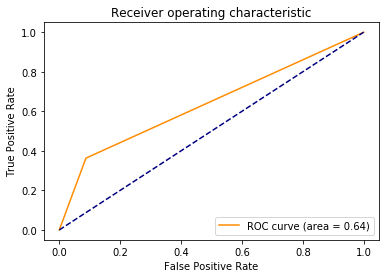

In [30]:
from sklearn.metrics import roc_curve, auc

y_pred = model_selection.cross_val_predict(Rf_model, X, y, cv=kfold)

fpr, tpr, thresholds = roc_curve(y, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()


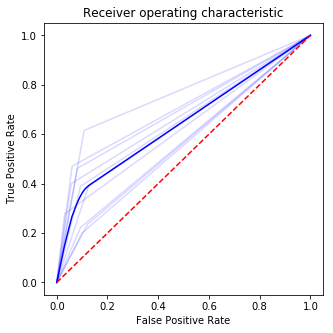

In [31]:
# Alternate approach to show ROC-AuC curve for each fold

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X=sc.fit_transform(X)
Y= y_f1.as_matrix(columns=None)

roc_auc=[]

tprs = []
base_fpr = np.linspace(0, 1, 101)

plt.figure(figsize=(5, 5))

for train,test in kfold.split(X,Y):
        Xtrain,Xtest=X[train,:],X[test,:]
        Ytrain,Ytest=Y[train],Y[test]
        Rf_model.fit(Xtrain,Ytrain)
        Y_predict=Rf_model.predict(Xtest)
        fpr,tpr, _ = roc_curve(Ytest,Y_predict)
        roc_auc.append(auc(fpr, tpr))
        
        plt.plot(fpr, tpr, 'b', alpha=0.15)
        tpr = np.interp(base_fpr, fpr, tpr)
        tpr[0] = 0.0
        tprs.append(tpr)

tprs = np.array(tprs)
mean_tprs = tprs.mean(axis=0)
std = tprs.std(axis=0)
tprs_upper = np.minimum(mean_tprs + std, 1)
tprs_lower = mean_tprs - std


plt.plot(base_fpr, mean_tprs, 'b')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('Receiver operating characteristic')
plt.show()



ROC curve can help you to choose a threshold that balances sensitivity and specificity in a way that makes sense for your particular context

# Q11. Calculate AUC(the percentage of the ROC plot that is underneath the curve) - optional

### Bootstrapping ( Bonus)
##### Given a dataset of size n, a bootstrap sample is created by sampling n instances uniformly from the data (with/without replacement)
##### Create a model with each bootstrap sample and validate it with the test set
##### Final result is calculated by averaging the accuracy of models

In [0]:
# Number of iterations for bootstrapping
bootstrap_iteration = 10
accuracy = []

In [0]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

for i in range(bootstrap_iteration):
    X_, y_ = resample(X_train, y_train)
    rfm.fit(X_, y_)
    y_pred = rfm.predict(X_test)
    
    acc = accuracy_score(y_pred, y_test)
    accuracy.append(acc)

In [0]:
accuracy = np.array(accuracy)
print('Accuracy Score')
print('Avearge: ', accuracy.mean())
print('Standard deviation: ', accuracy.std())

Accuracy Score
Avearge:  0.6893333333333334
Standard deviation:  0.014966629547095768
